Ваша задача - научить робота разумному, доброму и вечному, используя всю мощь обучения с подкреплением.


# Описание/Пошаговая инструкция выполнения домашнего задания:
- Возьмите среду Taxi из фреймворка gym: https://gym.openai.com/envs/.
- Определите и опишите какие у этой среды есть состояния и награды, а также какие действия можно совершать.
- Реализуйте один из алгоритмов поиска оптимальной стратегии: Value Iteration, Policy Iteration, Monte Carlo, SARSA, Q-learning.
- Получив оптимальную стратегию сыграйте 10 000 эпизодов и выведите оценку этой стратегии в виде средней награды за все игры и/или количество побед.
- Визуализируйте один эпизод игры с оптимальной стратегией.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from IPython.display import clear_output
import time
import random

# Воспроизводимость
SEED = 42
np.random.seed(SEED)
random.seed(SEED)


# Описание среды

In [14]:
# Создаём среду с ANSI-рендером
env = gym.make("Taxi-v4", render_mode="ansi")
obs, info = env.reset(seed=SEED)

# ── Основные параметры ──
n_states  = env.observation_space.n   
n_actions = env.action_space.n        
PASSENGER_LOCS = {0: "R(0,0)", 1: "G(0,4)", 2: "Y(4,0)", 3: "B(4,3)", 4: "в такси"}
DEST_LOCS      = {0: "R(0,0)", 1: "G(0,4)", 2: "Y(4,0)", 3: "B(4,3)"}
ACTION_NAMES   = {
    0: "⬇  Вниз",
    1: "⬆  Вверх",
    2: "➡  Вправо",
    3: "⬅  Влево",
    4: "🟢 Pickup",
    5: "🔴 Dropoff",
}


print("=" * 45)
print("         СРЕДА: Taxi-v4")
print("=" * 45)
print(f"  Пространство состояний : {n_states}")
print(f"  Пространство действий  : {n_actions}")
print()

# ── Действия ──

print("  ДЕЙСТВИЯ:")
for a, name in ACTION_NAMES.items():
    print(f"    [{a}] {name}")
print()

         СРЕДА: Taxi-v4
  Пространство состояний : 500
  Пространство действий  : 6

  ДЕЙСТВИЯ:
    [0] ⬇  Вниз
    [1] ⬆  Вверх
    [2] ➡  Вправо
    [3] ⬅  Влево
    [4] 🟢 Pickup
    [5] 🔴 Dropoff



In [15]:
# ── Декодирование состояния ──
# Состояние кодируется как:
#   state = taxi_row * 100 + taxi_col * 20 + passenger_loc * 4 + destination
def decode_state(state):
    """Возвращает (taxi_row, taxi_col, passenger_loc, destination)"""
    dest       = state % 4;         state //= 4
    passenger  = state % 5;         state //= 5
    taxi_col   = state % 5;         state //= 5
    taxi_row   = state
    return taxi_row, taxi_col, passenger, dest

taxi_r, taxi_c, pass_loc, dest_loc = decode_state(obs)
print(f"  НАЧАЛЬНОЕ СОСТОЯНИЕ (id={obs}):")
print(f"    Позиция такси    : ({taxi_r}, {taxi_c})")
print(f"    Пассажир         : {PASSENGER_LOCS[pass_loc]}")
print(f"    Назначение       : {DEST_LOCS[dest_loc]}")
print()

  НАЧАЛЬНОЕ СОСТОЯНИЕ (id=386):
    Позиция такси    : (3, 4)
    Пассажир         : G(0,4)
    Назначение       : Y(4,0)



In [17]:
#  Вывод политики 


def print_policy(policy, n=10, title="Политика"):
    """
    Выводит первые n состояний политики с расшифровкой каждого состояния.

    Параметры:
    ----------
    policy : np.array [n_states] — политика (action для каждого состояния)
    n      : int — сколько состояний вывести
    title  : str — заголовок таблицы
    """
    header = (f"{'s':>4} │ {'Такси':^7} │ {'Пассажир':^10} │ "
              f"{'Назначение':^10} │ {'Действие':<18}")
    sep    = "─" * len(header)

    print(f"\n  {title} (первые {n} состояний):")
    print(f"  {sep}")
    print(f"  {header}")
    for s in range(n):
        taxi_r, taxi_c, passenger, dest = decode_state(s)
        action = policy[s]

        print(f"  {s:>4} │ "
              f"({taxi_r},{taxi_c})  │ "
              f"{PASSENGER_LOCS[passenger]:^10} │ "
              f"{DEST_LOCS[dest]:^10} │ "
              f"{ACTION_NAMES[action]}")

    print(f"  {sep}")

    

In [7]:
# ── Структура reward table (P) ──
# env.unwrapped.P[state][action] = [(prob, next_state, reward, done), ...]
sample_state  = obs
sample_action = 0
transitions   = env.unwrapped.P[sample_state][sample_action]
print(f"  ТАБЛИЦА ПЕРЕХОДОВ P[state={sample_state}][action=0 (вниз)]:")
for prob, next_s, rew, done in transitions:
    r, c, p, d = decode_state(next_s)
    print(f"    P={prob:.1f} → state={next_s:3d} "
          f"(такси:({r},{c}), пасс:{passenger_locs[p]}, цель:{dest_locs[d]}) "
          f"| reward={rew:3d} | done={done}")
print()

  ТАБЛИЦА ПЕРЕХОДОВ P[state=386][action=0 (вниз)]:
    P=1.0 → state=486 (такси:(4,4), пасс:G(0,4), цель:Y(4,0)) | reward= -1 | done=False



In [8]:
# ── Визуализация начального состояния ──
print("  ВИЗУАЛИЗАЦИЯ:")
print(env.render())
print("=" * 45)
print("  Легенда:")
print("  Yellow/Blue/Red/Green = места назначения")
print("  Желтый фон = такси")
print("  Синий фон  = такси с пассажиром")

  ВИЗУАЛИЗАЦИЯ:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


  Легенда:
  Yellow/Blue/Red/Green = места назначения
  Желтый фон = такси
  Синий фон  = такси с пассажиром


In [20]:
# Универсальная оценка политики 

def evaluate_policy(policy, env_name="Taxi-v4", n_episodes=10_000,
                    max_steps=200, seed=42, algo_name="Алгоритм"):
    """
    Оценивает политику на n_episodes эпизодах.

    Политика может быть:
      - np.array [n_states]       — табличная (VI, PI, MC, SARSA, Q-learning)
      - callable(obs) -> action   — функция (DQN и любая нейросеть)

    Параметры:
    ----------
    policy    : np.array или callable
    env_name  : str  — название среды
    n_episodes: int  — количество эпизодов
    max_steps : int  — максимум шагов в эпизоде (защита от зависания)
    seed      : int  — начальный seed для воспроизводимости
    algo_name : str  — название алгоритма (для вывода)

    Возвращает:
    -----------
    dict с ключами:
      rewards  : list[float] — награда каждого эпизода
      steps    : list[int]   — длина каждого эпизода
      wins     : int         — число успешных эпизодов (reward > 0)
      mean_r   : float       — средняя награда
      std_r    : float       — стандартное отклонение награды
      win_rate : float       — доля побед (0..1)
      mean_steps: float      — средняя длина эпизода
    """
    env = gym.make(env_name)

    # Поддержка табличной политики и функции-политики (для DQN)
    if callable(policy):
        get_action = policy
    else:
        get_action = lambda obs: int(policy[obs])

    rewards, steps = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0

        for step in range(max_steps):
            action = get_action(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break

        rewards.append(ep_reward)
        steps.append(step + 1)

    env.close()

    results = {
        "rewards"   : rewards,
        "steps"     : steps,
        "wins"      : sum(r > 0 for r in rewards),
        "mean_r"    : float(np.mean(rewards)),
        "std_r"     : float(np.std(rewards)),
        "win_rate"  : float(np.mean([r > 0 for r in rewards])),
        "mean_steps": float(np.mean(steps)),
    }

    # ── Красивый вывод ──────────────────────────────────────────────────
    bar = "═" * 45
    print(f"\n  {bar}")
    print(f"  {'Оценка политики: ' + algo_name:^43}")
    print(f"  {bar}")
    print(f"  Эпизодов сыграно : {n_episodes:>10,}")
    print(f"  Побед (reward>0) : {results['wins']:>10,}  "
          f"({results['win_rate']*100:.1f}%)")
    print(f"  Средняя награда  : {results['mean_r']:>10.2f}  "
          f"± {results['std_r']:.2f}")
    print(f"  Средняя длина    : {results['mean_steps']:>10.1f}  шагов")
    print(f"  {bar}\n")

    return results

In [25]:
# Словарь, в котором храним результаты всех алгоритмов для удобного сравнения в конце
all_results = {}

# Value Iteration
ИДЕЯ: Итеративно применяем оператор Беллмана к функции ценности V(s).

Останавливаемся, когда максимальное изменение V(s) меньше порога

In [9]:
def value_iteration(env, gamma=0.99, theta=1e-8, max_iter=10_000):
    """
    Алгоритм Value Iteration.

    Параметры:
    ----------
    env      : среда gymnasium с доступом к env.unwrapped.P
    gamma    : коэффициент дисконтирования (0 < γ ≤ 1)
               γ близко к 1 → агент "дальновиден", ценит будущие награды
               γ близко к 0 → агент "жадный", ценит только ближайшую награду
    theta    : порог сходимости — останавливаемся, когда max|V_new - V_old| < θ
    max_iter : защита от бесконечного цикла

    Возвращает:
    -----------
    V      : np.array формы [n_states] — оптимальная функция ценности
    policy : np.array формы [n_states] — оптимальная детерминированная политика
    deltas : list — история max|ΔV| по итерациям (для графика сходимости)
    """

    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    P         = env.unwrapped.P   # P[s][a] = [(prob, s', r, done), ...]

    # Инициализируем V(s) = 0 для всех состояний
    # (можно любым числом — алгоритм сойдётся в любом случае)
    V = np.zeros(n_states)

    deltas = []   # будем сохранять δ каждой итерации

    for iteration in range(max_iter):

        delta = 0.0   # максимальное изменение V(s) на этой итерации

        # Проходим по всем состояниям
        for s in range(n_states):

            # Считаем Q(s, a) для каждого действия
            # Q(s,a) = Σ_{s'} P(s'|s,a) * [R(s,a,s') + γ * V(s')]
            q_values = np.zeros(n_actions)

            for a in range(n_actions):
                for prob, next_s, reward, done in P[s][a]:
                    # Если эпизод завершён в s', то V(s') = 0
                    # (терминальное состояние не имеет будущего)
                    q_values[a] += prob * (reward + gamma * V[next_s] * (not done))

            # Оператор Беллмана: берём максимум по действиям
            best_value = np.max(q_values)

            # Обновляем δ — насколько сильно изменилось V(s)
            delta = max(delta, abs(best_value - V[s]))

            # Обновляем V(s) прямо сейчас (in-place)
            # Это "синхронное" обновление — быстрее сходится
            V[s] = best_value

        deltas.append(delta)

        # Критерий остановки: V(s) практически не меняется
        if delta < theta:
            print(f"  Value Iteration сошёлся за {iteration + 1} итераций "
                  f"(δ = {delta:.2e} < θ = {theta:.2e})")
            break
    else:
        print(f"  Предупреждение: достигнут лимит итераций ({max_iter})")

    # ── Извлечение политики ────────────────────────────────────────────────
    # Когда V* найдена — делаем один жадный проход
    # π*(s) = argmax_a Q*(s, a)
    policy = np.zeros(n_states, dtype=int)

    for s in range(n_states):
        q_values = np.zeros(n_actions)

        for a in range(n_actions):
            for prob, next_s, reward, done in P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_s] * (not done))

        # argmax — выбираем действие с наибольшей ожидаемой ценностью
        policy[s] = np.argmax(q_values)

    return V, policy, deltas



In [28]:
print("Запускаем Value Iteration...")
print("-" * 45)

env_vi = gym.make("Taxi-v4", render_mode="ansi")

vi_V, vi_policy, vi_deltas = value_iteration(
    env_vi,
    gamma=0.99,
    theta=1e-8
)

print(f"\n  Диапазон V(s) : [{vi_V.min():.2f}, {vi_V.max():.2f}]")
print(f"  Пример политики (первые 10 состояний):")
print_policy(vi_policy, n=10, title="Политика Value Iteration")


Запускаем Value Iteration...
---------------------------------------------
  Value Iteration сошёлся за 13 итераций (δ = 0.00e+00 < θ = 1.00e-08)

  Диапазон V(s) : [1.15, 20.00]
  Пример политики (первые 10 состояний):

  Политика Value Iteration (первые 10 состояний):
  ─────────────────────────────────────────────────────────────
     s │  Такси  │  Пассажир  │ Назначение │ Действие          
     0 │ (0,0)  │   R(0,0)   │   R(0,0)   │ 🟢 Pickup
     1 │ (0,0)  │   R(0,0)   │   G(0,4)   │ 🟢 Pickup
     2 │ (0,0)  │   R(0,0)   │   Y(4,0)   │ 🟢 Pickup
     3 │ (0,0)  │   R(0,0)   │   B(4,3)   │ 🟢 Pickup
     4 │ (0,0)  │   G(0,4)   │   R(0,0)   │ ⬇  Вниз
     5 │ (0,0)  │   G(0,4)   │   G(0,4)   │ ⬇  Вниз
     6 │ (0,0)  │   G(0,4)   │   Y(4,0)   │ ⬇  Вниз
     7 │ (0,0)  │   G(0,4)   │   B(4,3)   │ ⬇  Вниз
     8 │ (0,0)  │   Y(4,0)   │   R(0,0)   │ ⬇  Вниз
     9 │ (0,0)  │   Y(4,0)   │   G(0,4)   │ ⬇  Вниз
  ─────────────────────────────────────────────────────────────


In [29]:
vi_results = evaluate_policy(vi_policy, algo_name="Value Iteration")
all_results["Value Iteration"] = vi_results


  ═════════════════════════════════════════════
       Оценка политики: Value Iteration      
  ═════════════════════════════════════════════
  Эпизодов сыграно :     10,000
  Побед (reward>0) :     10,000  (100.0%)
  Средняя награда  :       7.91  ± 2.61
  Средняя длина    :       13.1  шагов
  ═════════════════════════════════════════════



# Policy Iteration
 ИДЕЯ: Чередуем два шага до сходимости:
1. Policy Evaluation (оценка политики):
    Для фиксированной π вычисляем V^π(s) итеративно:
2. Policy Improvement (улучшение политики):
    Жадно обновляем политику по текущей V^π:


In [23]:
def policy_evaluation(policy, V, env, gamma, theta):
    """
    Шаг 1: итеративно оцениваем V^π для фиксированной политики.

    Параметры:
    ----------
    policy : np.array [n_states] — текущая детерминированная политика
    V      : np.array [n_states] — текущая оценка V (изменяется in-place)
    env    : среда с доступом к P
    gamma  : коэффициент дисконтирования
    theta  : порог сходимости внутреннего цикла
    """
    P        = env.unwrapped.P
    n_states = env.observation_space.n

    while True:
        delta = 0.0

        for s in range(n_states):
            a = policy[s]   # политика детерминирована — одно действие

            # V^π(s) 
            v_new = 0.0
            for prob, next_s, reward, done in P[s][a]:
                v_new += prob * (reward + gamma * V[next_s] * (not done))

            delta  = max(delta, abs(v_new - V[s]))
            V[s]   = v_new   # in-place обновление

        if delta < theta:
            break

    return V


def policy_improvement(V, env, gamma):
    """
    Шаг 2: жадно улучшаем политику по текущей V^π.

    Возвращает:
    -----------
    new_policy : np.array [n_states] — улучшенная политика
    """
    P         = env.unwrapped.P
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    new_policy = np.zeros(n_states, dtype=int)

    for s in range(n_states):
        q_values = np.zeros(n_actions)

        for a in range(n_actions):
            for prob, next_s, reward, done in P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_s] * (not done))

        new_policy[s] = np.argmax(q_values)

    return new_policy


def policy_iteration(env, gamma=0.99, theta=1e-8, max_iter=1000):
    """
    Полный алгоритм Policy Iteration.

    Возвращает:
    -----------
    V              : np.array [n_states] — оптимальная функция ценности
    policy         : np.array [n_states] — оптимальная политика
    n_iter         : int  — число внешних итераций до сходимости
    changes_history: list — сколько состояний меняло действие на каждой итерации
    """
    n_states = env.observation_space.n

    # Инициализация: V(s) = 0, политика = "всегда действие 0"
    V      = np.zeros(n_states)
    policy = np.zeros(n_states, dtype=int)

    changes_history = []

    for iteration in range(max_iter):

        # ── Шаг 1: полностью оцениваем текущую политику ───────────────────
        V = policy_evaluation(policy, V, env, gamma, theta)

        # ── Шаг 2: жадно улучшаем политику ───────────────────────────────
        new_policy = policy_improvement(V, env, gamma)

        # Считаем изменения
        n_changed = int(np.sum(new_policy != policy))
        changes_history.append(n_changed)

        print(f"  Итерация {iteration + 1:2d}: "
              f"изменилось состояний = {n_changed:4d}")

        # ── Policy Improvement Theorem: если π не изменилась — оптимум ───
        if n_changed == 0:
            print(f"\n  Policy Iteration сошёлся за {iteration + 1} итераций ✓")
            policy = new_policy
            break

        policy = new_policy

    return V, policy, iteration + 1, changes_history




In [30]:
print("Запускаем Policy Iteration...")
print("-" * 45)

env_pi = gym.make("Taxi-v4", render_mode="ansi")

pi_V, pi_policy, pi_n_iter, pi_changes = policy_iteration(
    env_pi,
    gamma=0.99,
    theta=1e-8
)


print_policy(pi_policy, n=10, title="Policy Iteration — оптимальная политика")



Запускаем Policy Iteration...
---------------------------------------------
  Итерация  1: изменилось состояний =    4
  Итерация  2: изменилось состояний =   20
  Итерация  3: изменилось состояний =   35
  Итерация  4: изменилось состояний =   36
  Итерация  5: изменилось состояний =   38
  Итерация  6: изменилось состояний =   40
  Итерация  7: изменилось состояний =   44
  Итерация  8: изменилось состояний =   61
  Итерация  9: изменилось состояний =   55
  Итерация 10: изменилось состояний =   51
  Итерация 11: изменилось состояний =   46
  Итерация 12: изменилось состояний =   31
  Итерация 13: изменилось состояний =   23
  Итерация 14: изменилось состояний =   21
  Итерация 15: изменилось состояний =   12
  Итерация 16: изменилось состояний =    3
  Итерация 17: изменилось состояний =    0

  Policy Iteration сошёлся за 17 итераций ✓

  Policy Iteration — оптимальная политика (первые 10 состояний):
  ─────────────────────────────────────────────────────────────
     s │  Такси  │

In [31]:
pi_results = evaluate_policy(pi_policy, algo_name="Policy Iteration")
all_results["Policy Iteration"] = pi_results


  ═════════════════════════════════════════════
       Оценка политики: Policy Iteration     
  ═════════════════════════════════════════════
  Эпизодов сыграно :     10,000
  Побед (reward>0) :     10,000  (100.0%)
  Средняя награда  :       7.91  ± 2.61
  Средняя длина    :       13.1  шагов
  ═════════════════════════════════════════════



# Monte Carlo (Every-Visit, ε-greedy)

ИДЕЯ: Агент играет эпизоды целиком, затем обновляет Q(s,a)
по фактически полученным наградам — никакой модели среды не нужно.


Для каждого эпизода:
  1. Сыграть эпизод политикой ε-greedy → получить траекторию
     [(s0,a0,r1), (s1,a1,r2), ..., (sT-1,aT-1,rT)]
  2. Для каждого шага t вычислить return (накопленная награда):
     G_t = r_{t+1} + γ*r_{t+2} + γ²*r_{t+3} + ... + γ^{T-t-1}*r_T
  3. Обновить Q(s_t, a_t) как скользящее среднее всех G_t
     которые мы видели для пары (s_t, a_t)



In [38]:
def monte_carlo(env_name="Taxi-v4", gamma=0.99,
                n_episodes=50_000,
                eps_start=1.0, eps_end=0.01, eps_decay=0.9995,
                seed=42):
    """
    Monte Carlo Every-Visit Control с ε-greedy исследованием.

    Параметры:
    ----------
    env_name  : str   — название среды
    gamma     : float — коэффициент дисконтирования
    n_episodes: int   — количество эпизодов обучения
    eps_start : float — начальное ε (полное исследование)
    eps_end   : float — минимальное ε (почти жадная политика)
    eps_decay : float — множитель уменьшения ε после каждого эпизода
    seed      : int   — seed для воспроизводимости

    Возвращает:
    -----------
    Q          : np.array [n_states, n_actions] — выученная Q-таблица
    policy     : np.array [n_states]            — жадная политика по Q
    ep_rewards : list[float]                    — награды по эпизодам (для графика)
    """
    env       = gym.make(env_name)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    # Q(s,a) — таблица ценностей пар (состояние, действие)
    # Инициализируем нулями
    Q = np.zeros((n_states, n_actions))

    # Returns(s,a) — счётчик и сумма для скользящего среднего
    # Q(s,a) = total_returns(s,a) / N(s,a)
    returns_sum   = np.zeros((n_states, n_actions))
    returns_count = np.zeros((n_states, n_actions))

    eps        = eps_start
    ep_rewards = []   # история наград для графика

    for ep in range(n_episodes):

        #  Шаг 1: разыгрываем эпизод ε-greedy политикой 
        obs, _ = env.reset(seed=seed + ep)
        trajectory = []   # список (state, action, reward)

        while True:
            # ε-greedy: исследуем или эксплуатируем
            if np.random.random() < eps:
                action = env.action_space.sample()          # Исследуем
            else:
                action = int(np.argmax(Q[obs]))             # Эксплуатируем

            next_obs, reward, terminated, truncated, _ = env.step(action)
            trajectory.append((obs, action, reward))
            obs = next_obs

            if terminated or truncated:
                break

        # Шаг 2: считаем returns с конца эпизода (эффективнее)
        # Идём с конца: G = 0, затем G = r_t + γ * G
        G = 0.0
        for state, action, reward in reversed(trajectory):
            G = reward + gamma * G

            # Every-Visit: обновляем при каждом появлении (s,a)
            returns_sum[state, action]   += G
            returns_count[state, action] += 1

            # Инкрементальное среднее: Q(s,a) = sum / count
            Q[state, action] = (returns_sum[state, action] /
                                returns_count[state, action])

        #  Шаг 3: уменьшаем ε 
        eps = max(eps_end, eps * eps_decay)

        # Сохраняем суммарную награду эпизода для графика
        ep_rewards.append(sum(r for _, _, r in trajectory))

        # Прогресс каждые 10 000 эпизодов
        if (ep + 1) % 10_000 == 0:
            mean_r = np.mean(ep_rewards[-1000:])   # среднее за последние 1000
            print(f"  Эпизод {ep+1:>6,} | ε={eps:.4f} | "
                  f"средняя награда (last 1k): {mean_r:+.2f}")

    env.close()

    # Извлекаем жадную политику из выученной Q-таблицы
    policy = np.argmax(Q, axis=1)

    return Q, policy, ep_rewards




In [53]:
print("Запускаем Monte Carlo...")
print("-" * 55)

mc_Q, mc_policy, mc_ep_rewards = monte_carlo(
    n_episodes=50_000,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.99995,
)

print_policy(mc_policy, n=10, title="Monte Carlo — выученная политика")


Запускаем Monte Carlo...
-------------------------------------------------------
  Эпизод 10,000 | ε=0.6065 | средняя награда (last 1k): -123.78
  Эпизод 20,000 | ε=0.3679 | средняя награда (last 1k): -53.75
  Эпизод 30,000 | ε=0.2231 | средняя награда (last 1k): -40.48
  Эпизод 40,000 | ε=0.1353 | средняя награда (last 1k): -35.99
  Эпизод 50,000 | ε=0.0821 | средняя награда (last 1k): -39.71

  Monte Carlo — выученная политика (первые 10 состояний):
  ─────────────────────────────────────────────────────────────
     s │  Такси  │  Пассажир  │ Назначение │ Действие          
     0 │ (0,0)  │   R(0,0)   │   R(0,0)   │ ⬇  Вниз
     1 │ (0,0)  │   R(0,0)   │   G(0,4)   │ 🟢 Pickup
     2 │ (0,0)  │   R(0,0)   │   Y(4,0)   │ 🟢 Pickup
     3 │ (0,0)  │   R(0,0)   │   B(4,3)   │ 🟢 Pickup
     4 │ (0,0)  │   G(0,4)   │   R(0,0)   │ ⬆  Вверх
     5 │ (0,0)  │   G(0,4)   │   G(0,4)   │ ⬇  Вниз
     6 │ (0,0)  │   G(0,4)   │   Y(4,0)   │ ➡  Вправо
     7 │ (0,0)  │   G(0,4)   │   B(4,3)   │ ⬇ 

In [50]:
mc_results = evaluate_policy(mc_policy, algo_name="Monte Carlo")
all_results["Monte Carlo"] = mc_results


  ═════════════════════════════════════════════
         Оценка политики: Monte Carlo        
  ═════════════════════════════════════════════
  Эпизодов сыграно :     10,000
  Побед (reward>0) :      5,384  (53.8%)
  Средняя награда  :     -87.67  ± 104.04
  Средняя длина    :       99.0  шагов
  ═════════════════════════════════════════════



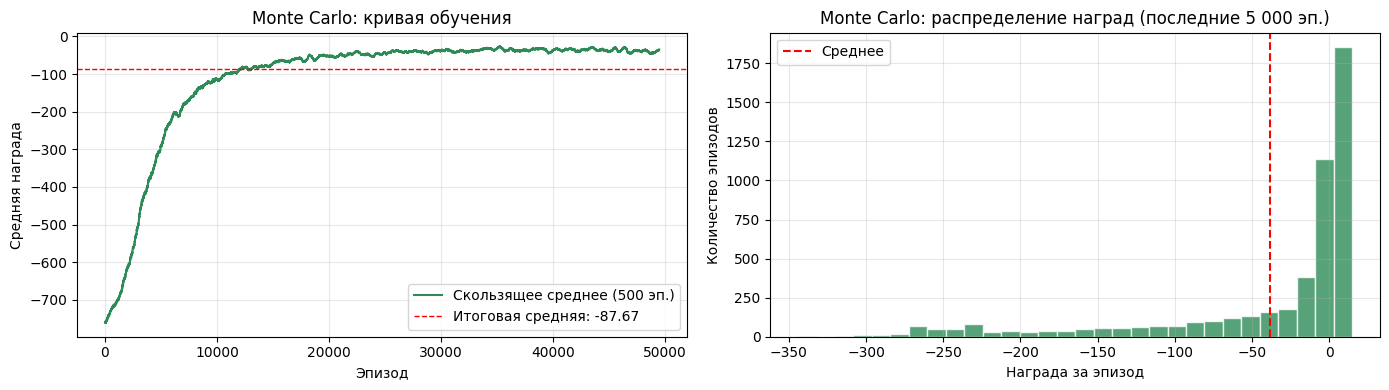

In [54]:
# График обучения Monte Carlo 

def smooth(values, window=500):
    """Скользящее среднее для сглаживания кривой обучения."""
    return np.convolve(values, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── График 1: кривая обучения (сглаженная) ──
smoothed = smooth(mc_ep_rewards, window=500)
axes[0].plot(smoothed, color="seagreen", linewidth=1.5,
             label="Скользящее среднее (500 эп.)")
axes[0].axhline(y=mc_results["mean_r"], color="red", linestyle="--",
                linewidth=1, label=f"Итоговая средняя: {mc_results['mean_r']:.2f}")
axes[0].set_xlabel("Эпизод")
axes[0].set_ylabel("Средняя награда")
axes[0].set_title("Monte Carlo: кривая обучения")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── График 2: распределение наград в конце обучения (последние 5000) ──
axes[1].hist(mc_ep_rewards[-5000:], bins=30,
             color="seagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(x=np.mean(mc_ep_rewards[-5000:]), color="red",
                linestyle="--", label="Среднее")
axes[1].set_xlabel("Награда за эпизод")
axes[1].set_ylabel("Количество эпизодов")
axes[1].set_title("Monte Carlo: распределение наград (последние 5 000 эп.)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mc_learning.png", dpi=120, bbox_inches="tight")
plt.show()

#  SARSA

ИДЕЯ: Обновляем Q(s,a) после КАЖДОГО шага, не дожидаясь конца эпизода.



In [43]:
def sarsa(env_name="Taxi-v4", gamma=0.99, alpha=0.1,
          n_episodes=50_000,
          eps_start=1.0, eps_end=0.01, eps_decay=0.9995,
          seed=42):
    """
    SARSA 

    Параметры:
    ----------
    env_name  : str   — название среды
    gamma     : float — коэффициент дисконтирования
    alpha     : float — шаг обучения (learning rate, 0 < α ≤ 1)
                        маленький α → медленное, но стабильное обучение
                        большой α  → быстрое, но нестабильное
    n_episodes: int   — количество эпизодов обучения
    eps_start : float — начальное ε
    eps_end   : float — минимальное ε
    eps_decay : float — множитель уменьшения ε
    seed      : int   — seed для воспроизводимости

    Возвращает:
    -----------
    Q          : np.array [n_states, n_actions] — выученная Q-таблица
    policy     : np.array [n_states]            — жадная политика по Q
    ep_rewards : list[float]                    — награды по эпизодам
    """
    env       = gym.make(env_name)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q          = np.zeros((n_states, n_actions))
    eps        = eps_start
    ep_rewards = []

    for ep in range(n_episodes):

        obs, _ = env.reset(seed=seed + ep)

        # ── Выбираем ПЕРВОЕ действие ε-greedy ─────────────────────────────
        # В SARSA нужно знать a' заранее — выбираем его ДО шага среды
        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[obs]))

        ep_reward = 0.0

        while True:

            # ── Шаг среды ─────────────────────────────────────────────────
            next_obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward

            # ── Выбираем СЛЕДУЮЩЕЕ действие a' ε-greedy ───────────────────
            # Это ключевой момент SARSA: a' выбирается ТОЙ ЖЕ политикой
            if np.random.random() < eps:
                next_action = env.action_space.sample()
            else:
                next_action = int(np.argmax(Q[next_obs]))

            # ── TD-обновление: Q(s,a) ← Q(s,a) + α*[R + γ*Q(s',a') - Q(s,a)]
            if terminated or truncated:
                # Терминальное состояние: Q(s_terminal, ·) = 0
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_obs, next_action]

            td_error       = td_target - Q[obs, action]
            Q[obs, action] += alpha * td_error

            # ── Переходим к следующему шагу ───────────────────────────────
            # ВАЖНО: следующее действие становится текущим
            obs    = next_obs
            action = next_action

            if terminated or truncated:
                break

        # ── Уменьшаем ε после каждого эпизода ────────────────────────────
        eps = max(eps_end, eps * eps_decay)
        ep_rewards.append(ep_reward)

        # Прогресс каждые 10 000 эпизодов
        if (ep + 1) % 10_000 == 0:
            mean_r = np.mean(ep_rewards[-1000:])
            print(f"  Эпизод {ep+1:>6,} | ε={eps:.4f} | "
                  f"средняя награда (last 1k): {mean_r:+.2f}")

    env.close()

    policy = np.argmax(Q, axis=1)
    return Q, policy, ep_rewards



In [46]:

# ── Запуск ─────────────────────────────────────────────────────────────────
print("Запускаем SARSA...")
print("-" * 55)

sarsa_Q, sarsa_policy, sarsa_ep_rewards = sarsa(
    n_episodes=50_000,
    gamma=0.99,
    alpha=0.1,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9995,
)
print_policy(sarsa_policy, n=10, title="SARSA — выученная политика")


Запускаем SARSA...
-------------------------------------------------------
  Эпизод 10,000 | ε=0.0100 | средняя награда (last 1k): +7.31
  Эпизод 20,000 | ε=0.0100 | средняя награда (last 1k): +7.23
  Эпизод 30,000 | ε=0.0100 | средняя награда (last 1k): +7.17
  Эпизод 40,000 | ε=0.0100 | средняя награда (last 1k): +7.17
  Эпизод 50,000 | ε=0.0100 | средняя награда (last 1k): +7.39

  SARSA — выученная политика (первые 10 состояний):
  ─────────────────────────────────────────────────────────────
     s │  Такси  │  Пассажир  │ Назначение │ Действие          
     0 │ (0,0)  │   R(0,0)   │   R(0,0)   │ ⬇  Вниз
     1 │ (0,0)  │   R(0,0)   │   G(0,4)   │ 🟢 Pickup
     2 │ (0,0)  │   R(0,0)   │   Y(4,0)   │ 🟢 Pickup
     3 │ (0,0)  │   R(0,0)   │   B(4,3)   │ 🟢 Pickup
     4 │ (0,0)  │   G(0,4)   │   R(0,0)   │ ⬇  Вниз
     5 │ (0,0)  │   G(0,4)   │   G(0,4)   │ ⬇  Вниз
     6 │ (0,0)  │   G(0,4)   │   Y(4,0)   │ ⬇  Вниз
     7 │ (0,0)  │   G(0,4)   │   B(4,3)   │ ⬇  Вниз
     8 │ (0,0) 

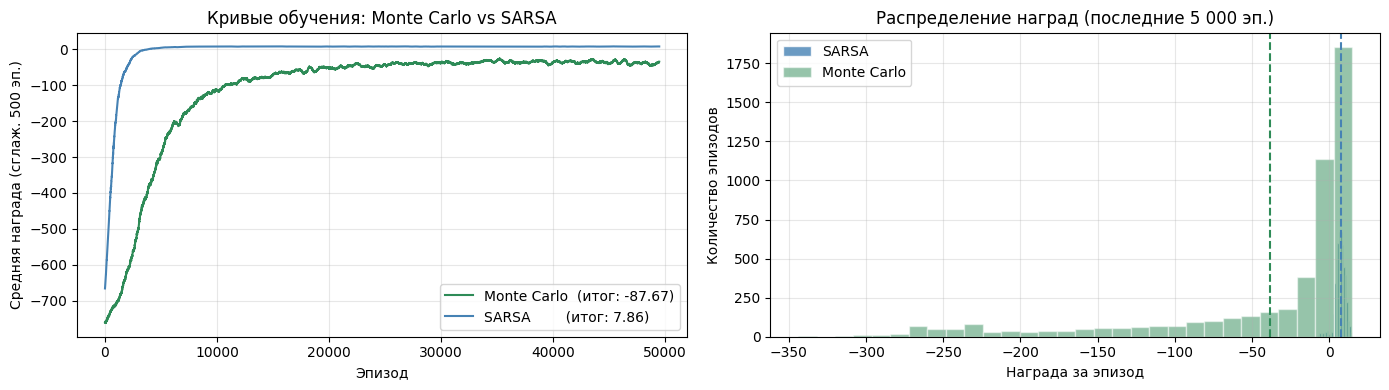

In [55]:
# График обучения SARSA 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── График 1: кривые обучения MC vs SARSA ──
# Удобно сравнивать сразу два алгоритма на одном графике
smoothed_mc    = smooth(mc_ep_rewards,    window=500)
smoothed_sarsa = smooth(sarsa_ep_rewards, window=500)

axes[0].plot(smoothed_mc,    color="seagreen", linewidth=1.5,
             label=f"Monte Carlo  (итог: {mc_results['mean_r']:.2f})")
axes[0].plot(smoothed_sarsa, color="steelblue", linewidth=1.5,
             label=f"SARSA        (итог: {sarsa_results['mean_r']:.2f})")
axes[0].set_xlabel("Эпизод")
axes[0].set_ylabel("Средняя награда (сглаж. 500 эп.)")
axes[0].set_title("Кривые обучения: Monte Carlo vs SARSA")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── График 2: распределение наград в конце обучения ──
axes[1].hist(sarsa_ep_rewards[-5000:], bins=30,
             color="steelblue", edgecolor="white", alpha=0.8,
             label="SARSA")
axes[1].hist(mc_ep_rewards[-5000:], bins=30,
             color="seagreen", edgecolor="white", alpha=0.5,
             label="Monte Carlo")
axes[1].axvline(x=np.mean(sarsa_ep_rewards[-5000:]),
                color="steelblue", linestyle="--")
axes[1].axvline(x=np.mean(mc_ep_rewards[-5000:]),
                color="seagreen", linestyle="--")
axes[1].set_xlabel("Награда за эпизод")
axes[1].set_ylabel("Количество эпизодов")
axes[1].set_title("Распределение наград (последние 5 000 эп.)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sarsa_learning.png", dpi=120, bbox_inches="tight")
plt.show()

In [47]:
sarsa_results = evaluate_policy(sarsa_policy, algo_name="SARSA")
all_results["SARSA"] = sarsa_results


  ═════════════════════════════════════════════
            Оценка политики: SARSA           
  ═════════════════════════════════════════════
  Эпизодов сыграно :     10,000
  Побед (reward>0) :     10,000  (100.0%)
  Средняя награда  :       7.86  ± 2.61
  Средняя длина    :       13.1  шагов
  ═════════════════════════════════════════════



# Q-learning

ИДЕЯ: Почти идентичен SARSA, но одно принципиальное отличие —

в формуле обновления используем не реальное следующее действие a',

а ЛУЧШЕЕ возможное действие max Q(s', ·).


In [59]:
def q_learning(env_name="Taxi-v4", gamma=0.99, alpha=0.1,
               n_episodes=50_000,
               eps_start=1.0, eps_end=0.01, eps_decay=0.9995,
               seed=42):
    """
    Q-learning — Off-Policy TD(0) Control (Watkins, 1989).

    Параметры:
    ----------
    env_name  : str   — название среды
    gamma     : float — коэффициент дисконтирования
    alpha     : float — шаг обучения
    n_episodes: int   — количество эпизодов обучения
    eps_start : float — начальное ε
    eps_end   : float — минимальное ε
    eps_decay : float — множитель уменьшения ε
    seed      : int   — seed для воспроизводимости

    Возвращает:
    -----------
    Q          : np.array [n_states, n_actions] — выученная Q-таблица
    policy     : np.array [n_states]            — жадная политика по Q
    ep_rewards : list[float]                    — награды по эпизодам
    """
    env       = gym.make(env_name)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q          = np.zeros((n_states, n_actions))
    eps        = eps_start
    ep_rewards = []

    for ep in range(n_episodes):

        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0.0

        while True:

            # ── Выбираем действие ε-greedy (behaviour policy) ─────────────
            if np.random.random() < eps:
                action = env.action_space.sample()        # exploration
            else:
                action = int(np.argmax(Q[obs]))           # exploitation

            # ── Шаг среды ─────────────────────────────────────────────────
            next_obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward

            # ── TD-обновление ─────────────────────────────────────────────
            # Мы НЕ выбираем next_action — берём максимум по всем действиям.
            # Именно это делает алгоритм off-policy.
            if terminated or truncated:
                td_target = reward                          # нет будущего
            else:
                td_target = reward + gamma * np.max(Q[next_obs])

            td_error       = td_target - Q[obs, action]
            Q[obs, action] += alpha * td_error

            obs = next_obs

            if terminated or truncated:
                break

        # ── Уменьшаем ε ───────────────────────────────────────────────────
        eps = max(eps_end, eps * eps_decay)
        ep_rewards.append(ep_reward)

        # Прогресс каждые 10 000 эпизодов
        if (ep + 1) % 10_000 == 0:
            mean_r = np.mean(ep_rewards[-1000:])
            print(f"  Эпизод {ep+1:>6,} | ε={eps:.4f} | "
                  f"средняя награда (last 1k): {mean_r:+.2f}")

    env.close()

    policy = np.argmax(Q, axis=1)
    return Q, policy, ep_rewards


# ── Запуск ─────────────────────────────────────────────────────────────────
print("Запускаем Q-learning...")
print("-" * 55)

ql_Q, ql_policy, ql_ep_rewards = q_learning(
    n_episodes=50_000,
    gamma=0.99,
    alpha=0.1,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9995,
)

print_policy(ql_policy, n=10, title="Q-learning — выученная политика")


Запускаем Q-learning...
-------------------------------------------------------
  Эпизод 10,000 | ε=0.0100 | средняя награда (last 1k): +7.35
  Эпизод 20,000 | ε=0.0100 | средняя награда (last 1k): +7.42
  Эпизод 30,000 | ε=0.0100 | средняя награда (last 1k): +7.28
  Эпизод 40,000 | ε=0.0100 | средняя награда (last 1k): +7.32
  Эпизод 50,000 | ε=0.0100 | средняя награда (last 1k): +7.45

  Q-learning — выученная политика (первые 10 состояний):
  ─────────────────────────────────────────────────────────────
     s │  Такси  │  Пассажир  │ Назначение │ Действие          
     0 │ (0,0)  │   R(0,0)   │   R(0,0)   │ ⬇  Вниз
     1 │ (0,0)  │   R(0,0)   │   G(0,4)   │ 🟢 Pickup
     2 │ (0,0)  │   R(0,0)   │   Y(4,0)   │ 🟢 Pickup
     3 │ (0,0)  │   R(0,0)   │   B(4,3)   │ 🟢 Pickup
     4 │ (0,0)  │   G(0,4)   │   R(0,0)   │ ⬇  Вниз
     5 │ (0,0)  │   G(0,4)   │   G(0,4)   │ ⬇  Вниз
     6 │ (0,0)  │   G(0,4)   │   Y(4,0)   │ ⬇  Вниз
     7 │ (0,0)  │   G(0,4)   │   B(4,3)   │ ➡  Вправо
   

In [60]:
ql_results = evaluate_policy(ql_policy, algo_name="Q-learning")
all_results["Q-learning"] = ql_results


  ═════════════════════════════════════════════
          Оценка политики: Q-learning        
  ═════════════════════════════════════════════
  Эпизодов сыграно :     10,000
  Побед (reward>0) :     10,000  (100.0%)
  Средняя награда  :       7.91  ± 2.61
  Средняя длина    :       13.1  шагов
  ═════════════════════════════════════════════



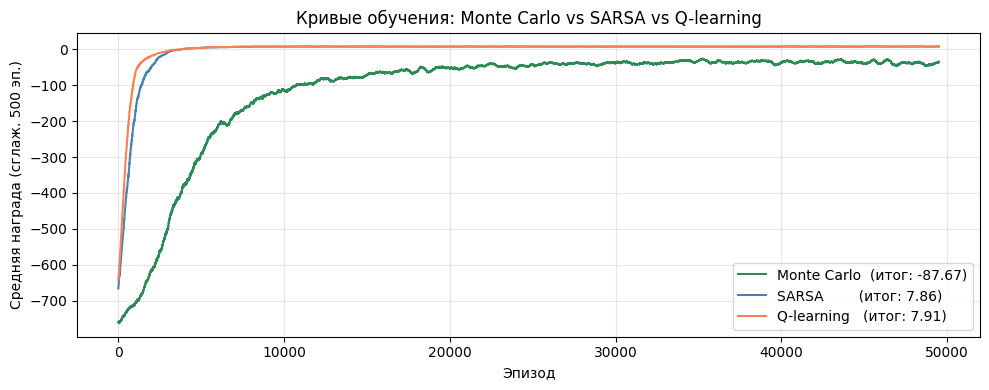

In [64]:
# График — MC vs SARSA vs Q-learning 


fig, ax = plt.subplots(figsize=(10, 4))

smoothed_ql = smooth(ql_ep_rewards, window=500)

ax.plot(smoothed_mc,    color="seagreen",  linewidth=1.5,
        label=f"Monte Carlo  (итог: {mc_results['mean_r']:.2f})")
ax.plot(smoothed_sarsa, color="steelblue", linewidth=1.5,
        label=f"SARSA        (итог: {sarsa_results['mean_r']:.2f})")
ax.plot(smoothed_ql,    color="coral",     linewidth=1.5,
        label=f"Q-learning   (итог: {ql_results['mean_r']:.2f})")

ax.set_xlabel("Эпизод")
ax.set_ylabel("Средняя награда (сглаж. 500 эп.)")
ax.set_title("Кривые обучения: Monte Carlo vs SARSA vs Q-learning")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ql_learning.png", dpi=120, bbox_inches="tight")
plt.show()

# DQN (Deep Q-Network) 

ИДЕЯ: Заменяем табличную Q(s,a) нейросетью Q(s,a; θ).

## Два ключевых трюка DQN (Mnih et al., 2015):

1. EXPERIENCE REPLAY (Replay Buffer):
- Сохраняем переходы (s,a,r,s',done) в буфер.
- На каждом шаге сэмплируем случайный мини-батч и учимся на нём.
2. TARGET NETWORK:
- Держим две одинаковые сети: online (θ) и target (θ⁻).
- TD-цель считаем через target: y = r + γ * max Q(s'; θ⁻)
- Веса target обновляем редко (каждые target_update шагов): θ⁻ ← θ

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

device = torch.device(
    "cuda"  if torch.cuda.is_available()    else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Используем устройство: {device}")


# ── Архитектура сети ───────────────────────────────────────────────────────
class DQNNetwork(nn.Module):
    """
    Q-сеть: state_id → Q(s, a) для всех действий.

    Embedding слой превращает дискретный индекс состояния
    в плотный обучаемый вектор — сеть сама учит,
    какие состояния "похожи" друг на друга.
    """

    def __init__(self, n_states, n_actions, embed_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Embedding(n_states, embed_dim),   # (batch,) → (batch, 64)
            nn.Flatten(),                         # на случай batch > 1
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),             # выход: Q для каждого действия
        )

    def forward(self, x):
        return self.net(x)


# ── Replay Buffer ──────────────────────────────────────────────────────────
class ReplayBuffer:
    """
    Кольцевой буфер для хранения переходов (s, a, r, s', done).

    При достижении capacity старые переходы перезаписываются.
    deque(maxlen=capacity) делает это автоматически.
    """

    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Добавляем один переход в буфер."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        Случайный мини-батч из буфера.
        Возвращаем тензоры на нужном устройстве.
        """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.tensor(states,      dtype=torch.long).to(device),
            torch.tensor(actions,     dtype=torch.long).to(device),
            torch.tensor(rewards,     dtype=torch.float32).to(device),
            torch.tensor(next_states, dtype=torch.long).to(device),
            torch.tensor(dones,       dtype=torch.float32).to(device),
        )

    def __len__(self):
        return len(self.buffer)



Используем устройство: mps


In [69]:

#  Основной алгоритм DQN
def dqn(env_name="Taxi-v4", gamma=0.99, alpha=1e-3,
        n_episodes=3_000,
        eps_start=1.0, eps_end=0.01, eps_decay=0.995,
        buffer_capacity=10_000, batch_size=64,
        target_update=100,
        seed=42):
    """
    DQN — Deep Q-Network (Mnih et al., 2015).

    Параметры:
    ----------
    env_name        : str   — название среды
    gamma           : float — коэффициент дисконтирования
    alpha           : float — learning rate для Adam оптимизатора
    n_episodes      : int   — количество эпизодов обучения
                              (DQN сходится быстрее табличных методов
                               в пересчёте на сложность среды)
    eps_start/end   : float — диапазон ε
    eps_decay       : float — множитель уменьшения ε (per episode)
    buffer_capacity : int   — размер Replay Buffer
    batch_size      : int   — размер мини-батча
    target_update   : int   — каждые N шагов копируем веса в target сеть
    seed            : int   — seed для воспроизводимости

    Возвращает:
    -----------
    online_net : обученная Q-сеть
    policy_fn  : callable(obs) -> action — функция политики для evaluate_policy
    ep_rewards : list[float]
    losses     : list[float] — история функции потерь
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env       = gym.make(env_name)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    # ── Две сети: online (учится) и target (стабилизирует цель) 
    online_net = DQNNetwork(n_states, n_actions).to(device)
    target_net = DQNNetwork(n_states, n_actions).to(device)
    target_net.load_state_dict(online_net.state_dict())  # одинаковые веса
    target_net.eval()   # target никогда не в режиме обучения

    optimizer = optim.Adam(online_net.parameters(), lr=alpha)
    loss_fn   = nn.HuberLoss(delta=1.0) 
    buffer    = ReplayBuffer(capacity=buffer_capacity)

    eps        = eps_start
    ep_rewards = []
    losses     = []
    total_steps = 0

    for ep in range(n_episodes):

        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0.0

        while True:

            # ── ε-greedy выбор действия ───────────────────────────────────
            if np.random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.tensor([obs], dtype=torch.long).to(device)
                    q_vals  = online_net(state_t)
                    action  = int(q_vals.argmax().item())

            # ── Шаг среды ─────────────────────────────────────────────────
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward

            # ── Сохраняем переход в Replay Buffer ─────────────────────────
            buffer.push(obs, action, reward, next_obs, float(done))
            obs = next_obs
            total_steps += 1

            # ── Обучение: только когда буфер достаточно заполнен ──────────
            if len(buffer) >= batch_size:
                states, actions, rewards, next_states, dones = buffer.sample(batch_size)

                # Текущие Q-значения: Q(s, a; θ)
                # gather выбирает Q-значение для выполненного действия
                q_current = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

                # TD-цель: y = r + γ * max Q(s'; θ⁻) * (1 - done)
                with torch.no_grad():
                    q_next  = target_net(next_states).max(1).values
                    q_target = rewards + gamma * q_next * (1.0 - dones)

                # Градиентный шаг
                loss = loss_fn(q_current, q_target)
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping — защита от взрывного градиента
                nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=1.0)
                optimizer.step()

                losses.append(loss.item())

            # ── Обновляем target сеть каждые target_update шагов ─────────
            if total_steps % target_update == 0:
                target_net.load_state_dict(online_net.state_dict())

            if done:
                break

        # ── Уменьшаем ε ───────────────────────────────────────────────────
        eps = max(eps_end, eps * eps_decay)
        ep_rewards.append(ep_reward)

        # Прогресс каждые 500 эпизодов
        if (ep + 1) % 500 == 0:
            mean_r = np.mean(ep_rewards[-100:])
            print(f"  Эпизод {ep+1:>5,} | ε={eps:.4f} | "
                  f"средняя награда (last 100): {mean_r:+.2f} | "
                  f"loss: {np.mean(losses[-100:]):.4f}")

    env.close()

    # ── Функция политики (callable) для evaluate_policy ───────────────────
    online_net.eval()

    def policy_fn(obs):
        with torch.no_grad():
            state_t = torch.tensor([obs], dtype=torch.long).to(device)
            return int(online_net(state_t).argmax().item())

    return online_net, policy_fn, ep_rewards, losses



In [70]:
print("Запускаем DQN...")
print("-" * 60)

dqn_net, dqn_policy_fn, dqn_ep_rewards, dqn_losses = dqn(
    n_episodes=3_000,
    gamma=0.99,
    alpha=1e-3,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.995,
    buffer_capacity=10_000,
    batch_size=64,
    target_update=100,
)



Запускаем DQN...
------------------------------------------------------------
  Эпизод   500 | ε=0.0816 | средняя награда (last 100): -65.63 | loss: 0.3533
  Эпизод 1,000 | ε=0.0100 | средняя награда (last 100): +2.05 | loss: 0.0363
  Эпизод 1,500 | ε=0.0100 | средняя награда (last 100): +4.30 | loss: 0.0168
  Эпизод 2,000 | ε=0.0100 | средняя награда (last 100): +5.92 | loss: 0.0058
  Эпизод 2,500 | ε=0.0100 | средняя награда (last 100): +6.29 | loss: 0.0053
  Эпизод 3,000 | ε=0.0100 | средняя награда (last 100): +4.95 | loss: 0.0059


In [72]:
dqn_results = evaluate_policy(dqn_policy_fn, algo_name="DQN")
all_results["DQN"] = dqn_results


  ═════════════════════════════════════════════
             Оценка политики: DQN            
  ═════════════════════════════════════════════
  Эпизодов сыграно :     10,000
  Побед (reward>0) :      9,941  (99.4%)
  Средняя награда  :       6.60  ± 16.14
  Средняя длина    :       14.3  шагов
  ═════════════════════════════════════════════



# Сравнение алгоритмов

In [73]:
colors = {
    "Value Iteration"  : "steelblue",
    "Policy Iteration" : "royalblue",
    "Monte Carlo"      : "seagreen",
    "SARSA"            : "coral",
    "Q-learning"       : "tomato",
    "DQN"              : "mediumpurple",
}

In [74]:
# Таблица результатов

print("=" * 75)
print(f"  {'Алгоритм':<20} {'Средняя награда':>16} {'±std':>8} "
      f"{'Побед %':>9} {'Ср. шагов':>10}")
print("=" * 75)

for name, res in all_results.items():
    print(f"  {name:<20} {res['mean_r']:>+16.2f} {res['std_r']:>8.2f} "
          f"{res['win_rate']*100:>8.1f}% {res['mean_steps']:>10.1f}")

print("=" * 75)

  Алгоритм              Средняя награда     ±std   Побед %  Ср. шагов
  Value Iteration                 +7.91     2.61    100.0%       13.1
  Policy Iteration                +7.91     2.61    100.0%       13.1
  Monte Carlo                    -87.67   104.04     53.8%       99.0
  SARSA                           +7.86     2.61    100.0%       13.1
  Q-learning                      +7.91     2.61    100.0%       13.1
  DQN                             +6.60    16.14     99.4%       14.3


DQN  видимо переобучил

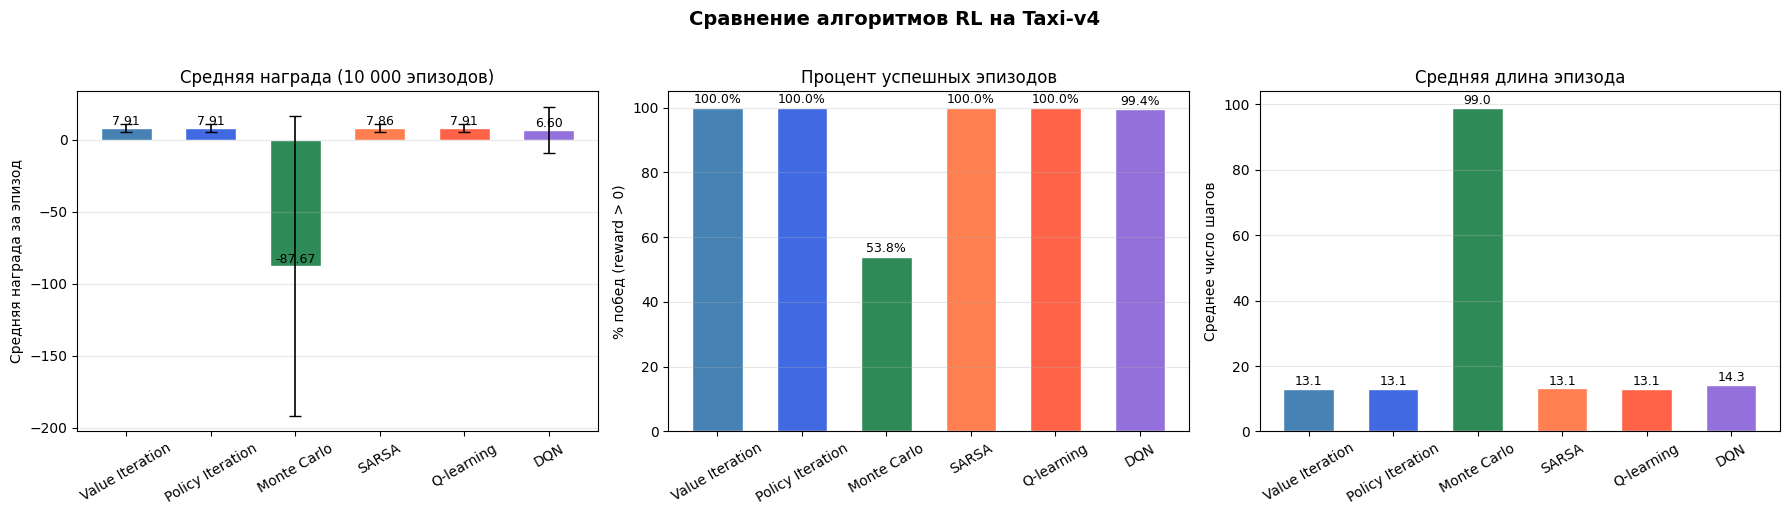

In [75]:
# Сравнительные графики 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names      = list(all_results.keys())
mean_rs    = [all_results[n]["mean_r"]        for n in names]
std_rs     = [all_results[n]["std_r"]         for n in names]
win_rates  = [all_results[n]["win_rate"] * 100 for n in names]
mean_steps = [all_results[n]["mean_steps"]    for n in names]
clrs       = [colors[n]                        for n in names]

# ── График 1: средняя награда с планками std ──
bars = axes[0].bar(names, mean_rs, color=clrs,
                   edgecolor="white", width=0.6)
axes[0].errorbar(names, mean_rs, yerr=std_rs,
                 fmt="none", color="black", capsize=4, linewidth=1.2)
axes[0].set_ylabel("Средняя награда за эпизод")
axes[0].set_title("Средняя награда (10 000 эпизодов)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, mean_rs):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.15, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=9)

# ── График 2: процент побед ──
bars2 = axes[1].bar(names, win_rates, color=clrs,
                    edgecolor="white", width=0.6)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel("% побед (reward > 0)")
axes[1].set_title("Процент успешных эпизодов")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars2, win_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.5, f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=9)

# ── График 3: средняя длина эпизода ──
bars3 = axes[2].bar(names, mean_steps, color=clrs,
                    edgecolor="white", width=0.6)
axes[2].set_ylabel("Среднее число шагов")
axes[2].set_title("Средняя длина эпизода")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars3, mean_steps):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.1, f"{val:.1f}",
                 ha="center", va="bottom", fontsize=9)

plt.suptitle("Сравнение алгоритмов RL на Taxi-v4",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

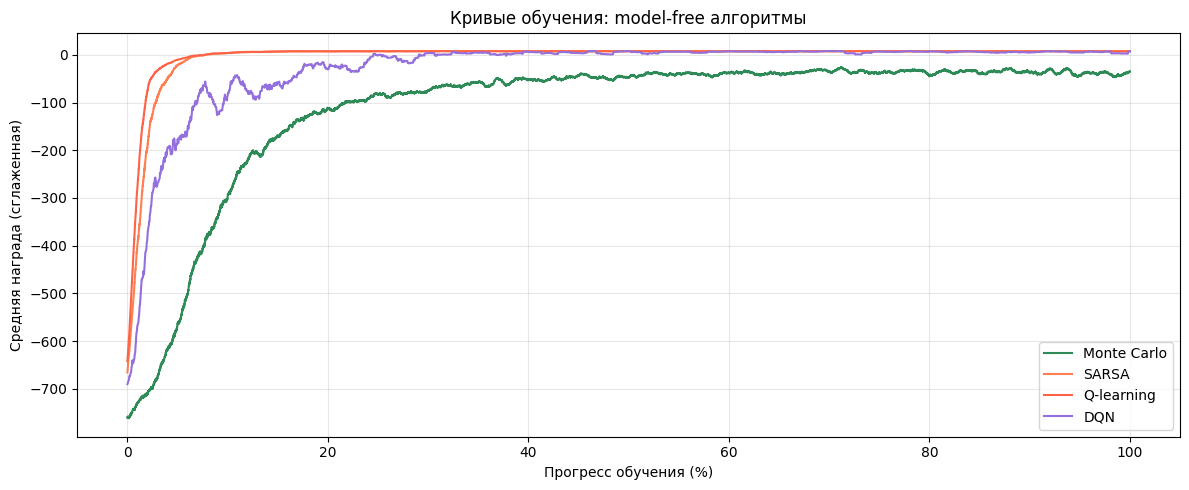

In [77]:
# Кривые обучения model-free алгоритмов ────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

learning_curves = {
    "Monte Carlo" : (mc_ep_rewards,    500,  "seagreen"),
    "SARSA"       : (sarsa_ep_rewards, 500,  "coral"),
    "Q-learning"  : (ql_ep_rewards,    500,  "tomato"),
    "DQN"         : (dqn_ep_rewards,   50,   "mediumpurple"),
}

for name, (rewards, window, color) in learning_curves.items():
    smoothed = smooth(rewards, window=window)
    # Нормализуем ось X до [0, 1] чтобы сравнивать алгоритмы
    # с разным числом эпизодов на одном графике
    x = np.linspace(0, 100, len(smoothed))
    ax.plot(x, smoothed, color=color, linewidth=1.5, label=name)

ax.set_xlabel("Прогресс обучения (%)")
ax.set_ylabel("Средняя награда (сглаженная)")
ax.set_title("Кривые обучения: model-free алгоритмы")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Визуализаци

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

# ── Константы среды ────────────────────────────────────────────────────────
GRID_SIZE  = 5

# Координаты 4 локаций (row, col) и их названия/цвета
LOCATIONS = {
    0: (0, 0, "R", "#e74c3c"),   # Red
    1: (0, 4, "G", "#2ecc71"),   # Green
    2: (4, 0, "Y", "#f1c40f"),   # Yellow
    3: (4, 3, "B", "#3498db"),   # Blue
}

# Стены среды Taxi — список ((row, col), направление)
# "right" = стена справа от клетки (col, col+1)
WALLS = [
    ((0, 1), "right"), ((1, 1), "right"),          # колонна между col=1 и col=2
    ((0, 2), "right"), ((1, 2), "right"),           # не стена — убираем дубль
    ((3, 0), "right"), ((4, 0), "right"),           # левая нижняя колонна
    ((3, 2), "right"), ((4, 2), "right"),           # правая нижняя колонна
]

def record_episode(policy, env_name="Taxi-v4", max_steps=50, seed=0):
    """
    Играем один эпизод и записываем все состояния.

    Возвращает:
    -----------
    frames : list of dict — каждый кадр содержит полное состояние среды
    """
    env    = gym.make(env_name)
    obs, _ = env.reset(seed=seed)

    if callable(policy):
        get_action = policy
    else:
        get_action = lambda o: int(policy[o])

    frames = []

    # Записываем начальное состояние
    taxi_r, taxi_c, pass_loc, dest_loc = decode_state(obs)
    frames.append({
        "step"      : 0,
        "taxi_r"    : taxi_r,
        "taxi_c"    : taxi_c,
        "pass_loc"  : pass_loc,
        "dest_loc"  : dest_loc,
        "action"    : None,
        "reward"    : 0,
        "total_r"   : 0,
        "done"      : False,
    })

    total_r = 0
    for step in range(1, max_steps + 1):
        action = get_action(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_r += reward

        taxi_r, taxi_c, pass_loc, dest_loc = decode_state(obs)
        frames.append({
            "step"    : step,
            "taxi_r"  : taxi_r,
            "taxi_c"  : taxi_c,
            "pass_loc": pass_loc,
            "dest_loc": dest_loc,
            "action"  : action,
            "reward"  : reward,
            "total_r" : total_r,
            "done"    : terminated or truncated,
        })

        if terminated or truncated:
            break

    env.close()
    print(f"  Эпизод записан: {len(frames)} кадров, "
          f"итоговая награда: {total_r:+.0f}")
    return frames


def draw_frame(ax, frame):
    """
    Рисует один кадр на переданном ax.
    """
    ax.clear()
    ax.set_xlim(-0.1, GRID_SIZE + 0.1)
    ax.set_ylim(-0.1, GRID_SIZE + 0.1)
    ax.set_aspect("equal")
    ax.axis("off")

    taxi_r    = frame["taxi_r"]
    taxi_c    = frame["taxi_c"]
    pass_loc  = frame["pass_loc"]
    dest_loc  = frame["dest_loc"]

    # ── Фон клеток ────────────────────────────────────────────────────────
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            # Переводим row → y: row=0 вверху, row=4 внизу
            y = GRID_SIZE - 1 - row
            rect = FancyBboxPatch(
                (col + 0.05, y + 0.05), 0.9, 0.9,
                boxstyle="round,pad=0.02",
                facecolor="#f8f9fa", edgecolor="#dee2e6", linewidth=1
            )
            ax.add_patch(rect)

    # ── Локации R/G/Y/B ───────────────────────────────────────────────────
    for loc_id, (r, c, label, color) in LOCATIONS.items():
        y = GRID_SIZE - 1 - r

        # Подсвечиваем назначение
        if loc_id == dest_loc:
            rect = FancyBboxPatch(
                (c + 0.05, y + 0.05), 0.9, 0.9,
                boxstyle="round,pad=0.02",
                facecolor=color, alpha=0.25,
                edgecolor=color, linewidth=2
            )
            ax.add_patch(rect)

        # Буква локации
        ax.text(c + 0.18, y + 0.75, label,
                fontsize=11, fontweight="bold", color=color,
                va="top", ha="left")

        # Пассажир ожидает здесь (не в такси)
        if pass_loc == loc_id:
            ax.text(c + 0.5, y + 0.38, "🧍",
                    fontsize=14, ha="center", va="center")

    # ── Такси ─────────────────────────────────────────────────────────────
    ty = GRID_SIZE - 1 - taxi_r

    # Цвет такси: жёлтый обычно, зелёный если пассажир внутри
    taxi_color = "#27ae60" if pass_loc == 4 else "#f39c12"
    taxi_bg = FancyBboxPatch(
        (taxi_c + 0.15, ty + 0.15), 0.7, 0.7,
        boxstyle="round,pad=0.05",
        facecolor=taxi_color, alpha=0.85,
        edgecolor="white", linewidth=1.5
    )
    ax.add_patch(taxi_bg)
    ax.text(taxi_c + 0.5, ty + 0.5, "🚕",
            fontsize=18, ha="center", va="center")

    # ── Стены ─────────────────────────────────────────────────────────────
    for (wr, wc), direction in WALLS:
        wy = GRID_SIZE - 1 - wr
        if direction == "right":
            ax.plot([wc + 1, wc + 1], [wy, wy + 1],
                    color="#2c3e50", linewidth=3, solid_capstyle="round")

    # ── Заголовок и инфо ──────────────────────────────────────────────────
    action_str = (ACTION_NAMES[frame["action"]]
                  if frame["action"] is not None else "Старт")

    status = "✅ Готово!" if frame["done"] else ""

    ax.set_title(
        f"Шаг {frame['step']}  |  {action_str}\n"
        f"Награда: {frame['reward']:+.0f}  |  "
        f"Итого: {frame['total_r']:+.0f}  {status}",
        fontsize=11, pad=8
    )


def animate_episode(frames, filename="taxi_episode.gif", fps=2):
    """
    Создаёт GIF из записанных кадров.

    Параметры:
    ----------
    frames   : list of dict — кадры из record_episode
    filename : str          — имя выходного файла
    fps      : int          — кадров в секунду (2 = медленно, удобно смотреть)
    """
    fig, ax = plt.subplots(figsize=(5, 5.5))
    fig.patch.set_facecolor("white")
    plt.tight_layout(pad=1.5)

    def update(i):
        draw_frame(ax, frames[i])

    anim = FuncAnimation(
        fig, update,
        frames=len(frames),
        interval=1000 / fps,   # миллисекунды между кадрами
        repeat=True
    )

    writer = PillowWriter(fps=fps)
    anim.save(filename, writer=writer, dpi=100)
    plt.close(fig)

    print(f"  GIF сохранён: {filename}  "
          f"({len(frames)} кадров, {fps} fps)")
    return filename




Записываем эпизод с политикой
  Эпизод записан: 16 кадров, итоговая награда: +6

Создаём GIF...


/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_23507/1179642179.py:203: UserWarning: Glyph 129485 (\N{STANDING PERSON}) missing from font(s) DejaVu Sans.
  anim.save(filename, writer=writer, dpi=100)
/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_23507/1179642179.py:203: UserWarning: Glyph 128661 (\N{TAXI}) missing from font(s) DejaVu Sans.
  anim.save(filename, writer=writer, dpi=100)
/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_23507/1179642179.py:203: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  anim.save(filename, writer=writer, dpi=100)
/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_23507/1179642179.py:203: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  anim.save(filename, writer=writer, dpi=100)
/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_23507/1179642179.py:203: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) D

  GIF сохранён: taxi_episode.gif  (16 кадров, 2 fps)


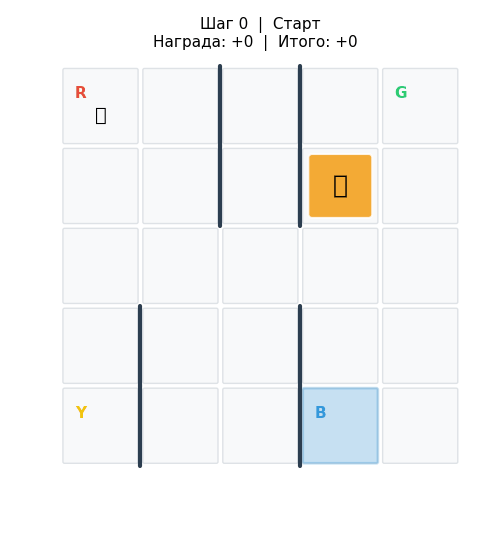

In [85]:
print("Записываем эпизод с политикой")
frames = record_episode(dqn_policy_fn, seed=8)

print("\nСоздаём GIF...")
gif_path = animate_episode(frames, filename="taxi_episode.gif", fps=2)

# Показываем GIF прямо в Jupyter
from IPython.display import Image
Image(gif_path)